# Activité 2 : Feature Engineering RFM & Prétraitement sur Online Retail

**Objectifs**
- Nettoyage approfondi des transactions brutes.
- Agrégation par `CustomerID` pour construire le dataset d'analyse RFM (Récence, Fréquence, Montant).
- Traitement de l'asymétrie des données (transformation `np.log1p`) et standardisation des variables.

## 1. Chargement et aperçu des données brutes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df_raw = pd.read_excel('Online_Retail.xlsx')
print("Dimensions :", df_raw.shape)
df_raw.head()

Dimensions : (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print("Valeurs manquantes :")
print(df_raw.isnull().sum())
print("\nAnnulations (InvoiceNo commençant par 'C') :", df_raw['InvoiceNo'].astype(str).str.startswith('C').sum())
print("Quantity <= 0 :", (df_raw['Quantity'] <= 0).sum())
print("UnitPrice <= 0 :", (df_raw['UnitPrice'] <= 0).sum())
print("Doublons exacts :", df_raw.duplicated().sum())
print("Clients uniques :", df_raw['CustomerID'].nunique())
print("Période :", df_raw['InvoiceDate'].min(), "->", df_raw['InvoiceDate'].max())

Valeurs manquantes :
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Annulations (InvoiceNo commençant par 'C') : 9288
Quantity <= 0 : 10624
UnitPrice <= 0 : 2517
Doublons exacts : 5268
Clients uniques : 4372
Période : 2010-12-01 08:26:00 -> 2011-12-09 12:50:00


**Constats** : une ligne correspond à un article dans une facture (et non à un client). Environ 25 % des lignes n'ont pas de `CustomerID`, et le fichier contient des annulations, des quantités ou prix négatifs ou nuls, et des doublons : un nettoyage est nécessaire avant toute agrégation.

## 2. Nettoyage des transactions

In [4]:
df = df_raw.copy()
etapes = [("Départ", len(df))]

# 1) Lignes sans CustomerID : non rattachables à un client
df = df.dropna(subset=['CustomerID'])
etapes.append(("Sans CustomerID manquant", len(df)))

# 2) Doublons exacts
df = df.drop_duplicates()
etapes.append(("Sans doublons", len(df)))

# 3) Annulations (InvoiceNo commençant par 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
etapes.append(("Sans annulations", len(df)))

# 4) Quantités et prix négatifs ou nuls
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
etapes.append(("Quantité et prix > 0", len(df)))

# 5) Codes qui ne sont pas des produits (frais de port, saisies manuelles...)
df = df[~df['StockCode'].astype(str).isin(['POST', 'M', 'PADS', 'DOT'])]
etapes.append(("Sans codes non-produits", len(df)))

# 6) Types utiles et montant d'une ligne
df['CustomerID'] = df['CustomerID'].astype(int)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

pd.DataFrame(etapes, columns=['Étape', 'Nombre de lignes'])

,Étape,Nombre de lignes
0,Départ,541909
1,Sans CustomerID manquant,406829
2,Sans doublons,401604
3,Sans annulations,392732
4,Quantité et prix > 0,392692
5,Sans codes non-produits,391295


**Justification** : les lignes sans client ne peuvent pas être segmentées ; les annulations, quantités et prix négatifs ou nuls ne sont pas de vrais achats ; les doublons fausseraient la fréquence et le montant. Les codes `POST` et `DOT` (frais de port) et `M` (saisies manuelles) ne sont pas des produits, et `PADS` est une ligne atypique (4 lignes seulement, prix quasi nul). Les annulations ont été supprimées plutôt que déduites des achats, ce qui est plus simple mais écarte les retours de marchandise.

## 3. Agrégation par client : construction du dataset RFM

In [5]:
# Date de référence : le lendemain de la dernière transaction
date_ref = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (date_ref - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print("Nombre de clients :", rfm.shape[0])
rfm.describe().round(1)

Nombre de clients : 4335


,CustomerID,Recency,Frequency,Monetary
count,4335.0,4335.0,4335.0,4335.0
mean,15299.4,92.7,4.2,2017.1
std,1721.8,100.2,7.6,8919.4
min,12346.0,1.0,1.0,3.8
25%,13812.5,18.0,1.0,304.2
50%,15298.0,51.0,2.0,663.6
75%,16778.5,143.0,5.0,1631.5
max,18287.0,374.0,206.0,279138.0


**Définition des variables** : `Recency` = nombre de jours depuis le dernier achat (plus elle est faible, plus le client est récent) ; `Frequency` = nombre de factures distinctes ; `Monetary` = montant total dépensé.

## 4. Asymétrie des variables et transformation `log1p`

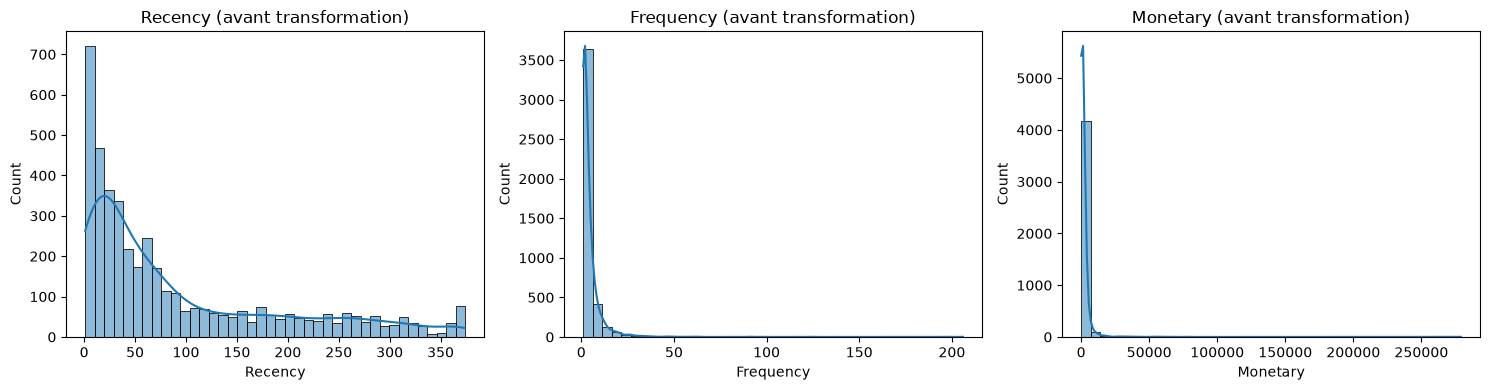

Asymétrie avant :
Recency       1.24
Frequency    11.97
Monetary     19.55
dtype: float64


In [6]:
variables = ['Recency', 'Frequency', 'Monetary']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var in zip(axes, variables):
    sns.histplot(rfm[var], bins=40, kde=True, ax=ax)
    ax.set_title(f'{var} (avant transformation)')
plt.tight_layout()
plt.show()

print("Asymétrie avant :")
print(rfm[variables].skew().round(2))

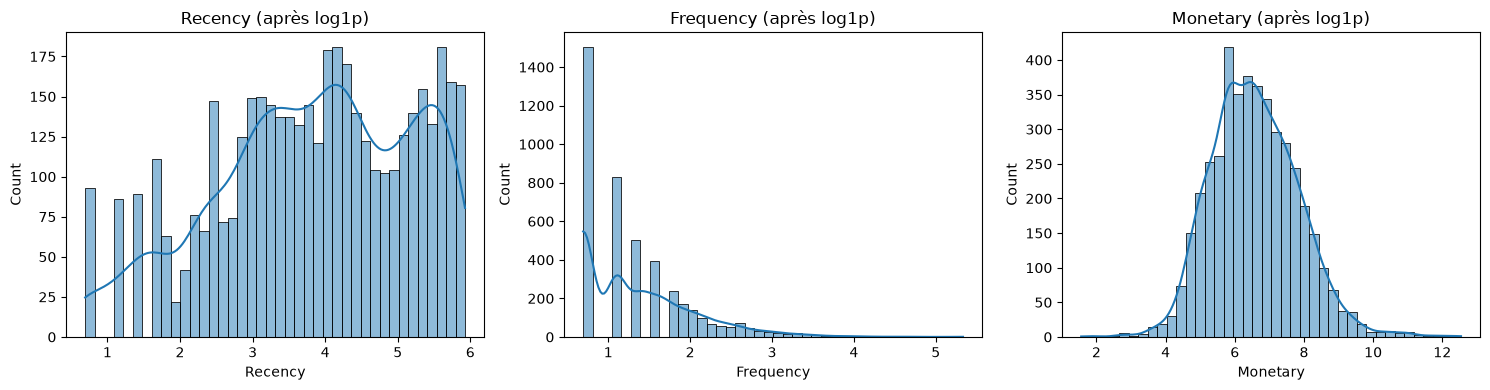

Asymétrie après log1p :
Recency     -0.38
Frequency    1.21
Monetary     0.40
dtype: float64


In [7]:
rfm_log = rfm.copy()
rfm_log[variables] = np.log1p(rfm_log[variables])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var in zip(axes, variables):
    sns.histplot(rfm_log[var], bins=40, kde=True, ax=ax)
    ax.set_title(f'{var} (après log1p)')
plt.tight_layout()
plt.show()

print("Asymétrie après log1p :")
print(rfm_log[variables].skew().round(2))

**Interprétation** : avant transformation, la fréquence (asymétrie d'environ 12) et surtout le montant (environ 19,6) sont très asymétriques : quelques clients très actifs dominent. Après `log1p`, les asymétries tombent à environ 1,2 pour la fréquence et 0,4 pour le montant, et la récence devient presque symétrique (environ -0,4). La transformation compresse les grandes valeurs, ce qui évite que K-means soit dominé par les clients extrêmes. On applique `log1p` avant la standardisation, car `log1p` est défini pour toute valeur positive ou nulle.

## 5. Standardisation

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = pd.DataFrame(scaler.fit_transform(rfm_log[variables]), columns=variables)

print("Moyenne et écart-type après standardisation :")
display(rfm_scaled.describe().loc[['mean', 'std']].round(2))
rfm_scaled.head()

Moyenne et écart-type après standardisation :


,Recency,Frequency,Monetary
mean,0.0,0.0,0.0
std,1.0,1.0,1.0


,Recency,Frequency,Monetary
0,1.460165,-0.951420,3.726618
1,-2.037990,1.081712,1.428561
2,0.372077,0.392407,0.554153
3,-0.623381,-0.951420,0.565323
4,1.422757,-0.951420,-0.706655


**Vérification** : chaque variable a une moyenne de 0 et un écart-type de 1, donc aucune ne domine le calcul des distances. Le jeu de données `rfm_scaled` (4 335 clients, 3 variables) est prêt pour le clustering ; `rfm` conserve les valeurs d'origine pour interpréter les clusters en jours, en commandes et en livres sterling. Après `log1p`, la fréquence et le montant sont fortement corrélés (environ 0,81), point à garder en tête pour l'interprétation.

In [9]:
print("Corrélations (après log1p) :")
rfm_log[variables].corr().round(2)

Corrélations (après log1p) :


,Recency,Frequency,Monetary
Recency,1.00,-0.57,-0.49
Frequency,-0.57,1.00,0.81
Monetary,-0.49,0.81,1.00


## 6. Analyses complémentaires

Cinq questions pour justifier le prétraitement, vérifier les variables RFM et comprendre les segments de clients. Les cellules doivent être exécutées dans l'ordre : la question 5 crée la colonne `Cluster` dans `rfm`.

### Question 1 : pourquoi faut-il transformer les variables avec `log1p` ?

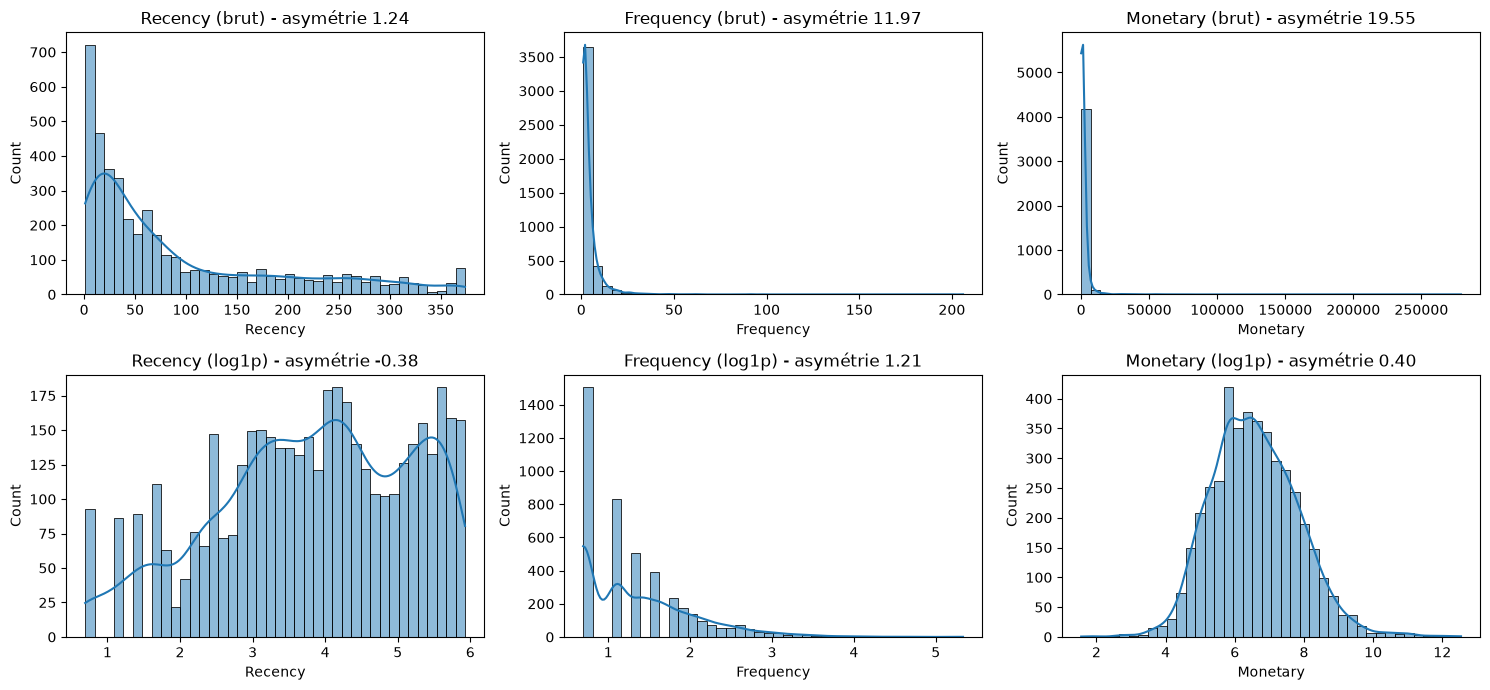

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for j, var in enumerate(variables):
    sns.histplot(rfm[var], bins=40, kde=True, ax=axes[0, j])
    axes[0, j].set_title(f'{var} (brut) - asymétrie {rfm[var].skew():.2f}')
    sns.histplot(rfm_log[var], bins=40, kde=True, ax=axes[1, j])
    axes[1, j].set_title(f'{var} (log1p) - asymétrie {rfm_log[var].skew():.2f}')
plt.tight_layout()
plt.show()

**Commentaire :** ce graphique compare les distributions avant (ligne du haut) et après (ligne du bas) la transformation `log1p`. Nous voulons démontrer que la fréquence et surtout le montant sont très asymétriques : la plupart des clients dépensent peu, et quelques-uns dépensent énormément (asymétries d'environ 12 et 19,6). Sans transformation, ces valeurs extrêmes domineraient le calcul des distances et fausseraient K-means. Après `log1p`, les distributions sont beaucoup plus équilibrées (asymétries d'environ 1,2 et 0,4), ce qui justifie cette étape de prétraitement.

### Question 2 : les trois variables RFM apportent-elles des informations différentes ?

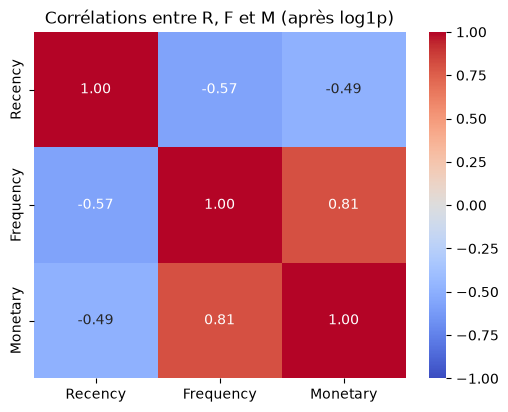

In [11]:
plt.figure(figsize=(6, 4.5))
sns.heatmap(rfm_log[variables].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Corrélations entre R, F et M (après log1p)')
plt.show()

**Commentaire :** nous cherchons à savoir si certaines variables sont redondantes avant le clustering. La fréquence et le montant sont fortement corrélés (environ 0,81) : un client qui commande souvent dépense logiquement davantage. La récence est corrélée négativement aux deux (environ -0,57 et -0,49) : les clients récents sont aussi les plus actifs. La fréquence et le montant portent donc en partie la même information, ce qu'il faudra garder en tête pour interpréter les clusters. Nous conservons néanmoins les trois variables, car elles décrivent trois dimensions complémentaires du comportement d'achat.

### Question 3 : le chiffre d'affaires dépend-il d'un petit nombre de clients ?

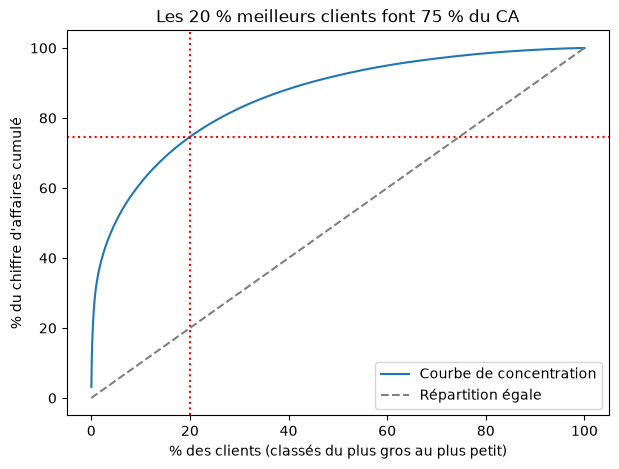

In [12]:
ca = rfm.sort_values('Monetary', ascending=False)['Monetary'].reset_index(drop=True)
part_clients = (np.arange(1, len(ca) + 1) / len(ca)) * 100
part_ca = ca.cumsum() / ca.sum() * 100
top20 = part_ca[int(0.2 * len(ca)) - 1]

plt.figure(figsize=(7, 5))
plt.plot(part_clients, part_ca, label='Courbe de concentration')
plt.plot([0, 100], [0, 100], '--', color='grey', label='Répartition égale')
plt.axvline(20, color='red', linestyle=':')
plt.axhline(top20, color='red', linestyle=':')
plt.xlabel('% des clients (classés du plus gros au plus petit)')
plt.ylabel("% du chiffre d'affaires cumulé")
plt.title(f'Les 20 % meilleurs clients font {top20:.0f} % du CA')
plt.legend()
plt.show()

**Commentaire :** cette courbe de concentration (type Pareto) montre quelle part du chiffre d'affaires est générée par les meilleurs clients. Plus la courbe s'éloigne de la diagonale (répartition égale), plus l'activité est concentrée. Ici, les 20 % meilleurs clients génèrent environ 75 % du chiffre d'affaires. Nous voulons démontrer que tous les clients n'ont pas la même valeur, ce qui justifie la segmentation : les actions marketing doivent être différentes selon les groupes, avec une attention particulière aux meilleurs clients.

### Question 4 : combien de segments de clients distincts existe-t-il ?

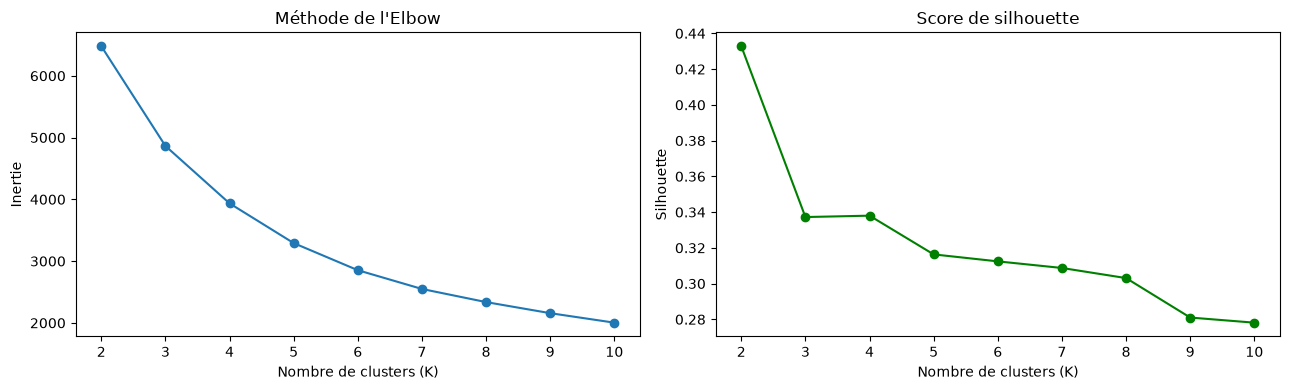

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 11)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=0, n_init=10).fit(rfm_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(rfm_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(ks), inertias, marker='o')
axes[0].set_title("Méthode de l'Elbow")
axes[0].set_xlabel('Nombre de clusters (K)')
axes[0].set_ylabel('Inertie')
axes[1].plot(list(ks), sils, marker='o', color='green')
axes[1].set_title('Score de silhouette')
axes[1].set_xlabel('Nombre de clusters (K)')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

**Commentaire :** nous cherchons le nombre de clusters à retenir avec deux critères complémentaires : l'inertie (le coude de la courbe) et le score de silhouette (qualité de la séparation des clusters). Ici, le coude est progressif et peu net. La silhouette est la plus élevée pour K = 2 (environ 0,43), mais cette solution sépare seulement les clients actifs des clients inactifs, ce qui est trop grossier pour un usage marketing. Pour K = 3 ou 4, elle reste d'environ 0,34. Nous retenons donc K = 4, un compromis entre qualité statistique et segments interprétables.

### Question 5 : quels sont les profils des clusters et leur poids économique ?

,Recency,Frequency,Monetary,Effectif,% CA
Cluster,,,,,
0,18.3,2.1,532.9,835,5.1
1,182.9,1.3,349.0,1628,6.5
2,68.3,4.1,1790.1,1182,24.2
3,11.8,13.9,8137.8,690,64.2


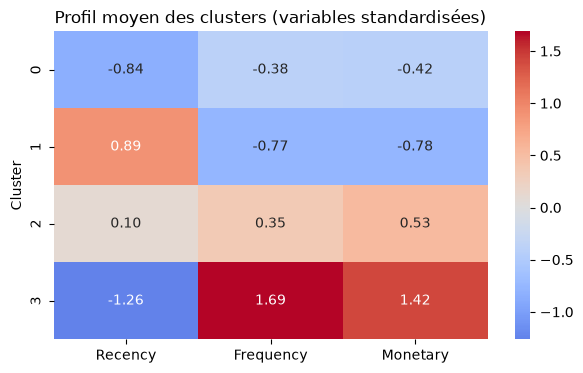

In [14]:
K = 4
km = KMeans(n_clusters=K, random_state=0, n_init=10).fit(rfm_scaled)
rfm['Cluster'] = km.labels_

# Profils en valeurs d'origine
profils = rfm.groupby('Cluster')[variables].mean().round(1)
profils['Effectif'] = rfm['Cluster'].value_counts().sort_index()
profils['% CA'] = (rfm.groupby('Cluster')['Monetary'].sum() / rfm['Monetary'].sum() * 100).round(1)
display(profils)

# Heatmap des profils (variables standardisées)
z = rfm_scaled.copy()
z['Cluster'] = rfm['Cluster']
plt.figure(figsize=(7, 4))
sns.heatmap(z.groupby('Cluster')[variables].mean(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Profil moyen des clusters (variables standardisées)')
plt.show()

**Commentaire :** la heatmap montre, pour chaque cluster, si ses clients sont au-dessus (rouge) ou en dessous (bleu) de la moyenne sur chaque variable, ce qui permet de nommer les segments. Nous obtenons quatre profils : les **meilleurs clients** (environ 690 clients, récents, environ 14 commandes, 8 138 £ en moyenne), qui font environ 64 % du chiffre d'affaires ; les **clients réguliers** (environ 1 180 clients, environ 24 % du CA) ; les **clients récents peu actifs** (environ 835 clients, acheteurs récents mais avec peu de commandes) ; et les **clients perdus** (environ 1 630 clients, dernier achat il y a environ 183 jours, seulement 6,5 % du CA). Nous voulons démontrer que chaque segment appelle une action marketing différente : fidéliser les meilleurs clients, développer les réguliers, activer les nouveaux et relancer les inactifs.

## Conclusion

- **Nettoyage** : de 541 909 lignes brutes, il reste 391 295 transactions valides, rattachées à 4 335 clients.
- **Dataset RFM** : chaque client est décrit par sa récence, sa fréquence et son montant. Ces variables étant très asymétriques (surtout la fréquence et le montant), nous les avons transformées avec `log1p`, puis standardisées pour qu'aucune ne domine le calcul des distances.
- **Concentration** : les 20 % meilleurs clients génèrent environ 75 % du chiffre d'affaires.
- **Segmentation** : avec K = 4, nous obtenons des segments distincts (meilleurs clients, clients réguliers, clients récents peu actifs, clients perdus). Les 690 meilleurs clients (environ 16 % de la base) font environ 64 % du chiffre d'affaires, ce qui justifie de cibler les actions marketing selon le segment.
- **Limites** : le coude est peu marqué, donc le choix de K = 4 repose en partie sur l'interprétabilité des segments. Les annulations ont été supprimées au lieu d'être déduites des achats.